In [ ]:
# %pip install -r requirements.txt  # if needed

In [2]:
import os, sys, json, random, time, yaml
from pathlib import Path
import torch, pandas as pd, matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from tqdm.auto import tqdm
sys.path.append(r"C:\work projects\ITMO\NIR\external")
sys.path.append(r"C:\work projects\ITMO\NIR\external\codebleu")
from codebleu.my_calc_code_blue import calc_codebleu
device='cuda' if torch.cuda.is_available() else 'cpu'
torch.backends.cuda.matmul.allow_tf32=True
print('Device:',device)

Device: cuda


In [3]:
CFG_BASE=yaml.safe_load(open('baseline_prompt.yaml','r',encoding='utf8'))
CFG_EXTRA=yaml.safe_load(open('big_run.yaml','r',encoding='utf8'))
SAMPLE_SIZE=CFG_EXTRA['sample_size']; N_ITERS=CFG_EXTRA['n_iters']; BATCH_SIZE=CFG_EXTRA['batch']
SAVE_DIR=Path('results')/('full_'+time.strftime('%Y%m%d_%H%M%S')); SAVE_DIR.mkdir(parents=True,exist_ok=True)
print('Save dir:',SAVE_DIR)

Save dir: results\full_20250629_152057


In [4]:
def load_jsonl(p,sample=None):
    rows=[json.loads(l) for l in open(p,encoding='utf8')]
    if sample and len(rows)>sample: rows=random.sample(rows,sample)
    return Dataset.from_list(rows)
datasets={}
for n,s in CFG_BASE['datasets'].items():
    ds=load_jsonl(Path(CFG_BASE['root'])/s['file'], SAMPLE_SIZE)
    datasets[n]={'data':ds,'template':s['template'],'max_tok':s['max_new_tokens']}
    print(n,len(ds))

humaneval 100
mbpp 374
conala 95
conala_mined 4999


In [5]:
MODEL_NAME=CFG_BASE['model_name']
tokenizer=AutoTokenizer.from_pretrained(MODEL_NAME,trust_remote_code=True)
model=AutoModelForCausalLM.from_pretrained(MODEL_NAME,torch_dtype=torch.float16).to('cuda').eval()
print('Model on',next(model.parameters()).device)

Model on cuda:0


In [6]:
@torch.no_grad()
def evaluate(ds,template,max_tok):
    preds,refs,lats=[],[],[]
    for row in tqdm(ds):
        prompt=template.replace('{input}',row['input'])
        ids=tokenizer(prompt,return_tensors='pt').to(device)
        t0=time.time()
        out=model.generate(**ids,max_new_tokens=max_tok,do_sample=False,num_beams=1,
                           pad_token_id=tokenizer.eos_token_id)
        lats.append((time.time()-t0)*1000)
        gen=tokenizer.decode(out[0],skip_special_tokens=True)[len(prompt):].strip()
        preds.append(gen); refs.append(row['target'].strip())
    em=sum(p==r for p,r in zip(preds,refs))/len(refs)
    cb=calc_codebleu(refs,preds,lang='python',weights=(0.5,0.5,0,0))['codebleu']
    return {'EM':em,'CodeBLEU':cb,'Latency':sum(lats)/len(lats)}

In [7]:
class AutoPrompt:
    def __init__(self,model,tok,n_tokens=3,lr=1e-1,batch=BATCH_SIZE):
        self.model=model; self.tok=tok; self.n_tokens=n_tokens; self.batch=batch
        V=tok.vocab_size
        self.logits=torch.nn.Parameter(torch.randn(n_tokens,V,device=device)*0.01)
        self.opt=torch.optim.Adam([self.logits],lr=lr); self.loss=[]
    def _soft(self):
        p=torch.softmax(self.logits,dim=-1); emb=self.model.get_input_embeddings().weight
        return (p.to(emb.dtype) @ emb)
    def train(self,ds,iters):
        for it in range(iters):
            tot=0; be,bl=[],[]
            for i,r in enumerate(ds):
                inp=self.tok(r['input'],return_tensors='pt').input_ids[0].to(device)
                tgt=self.tok(r['target'],return_tensors='pt').input_ids[0].to(device)
                seq_emb=self.model.get_input_embeddings()(torch.cat([inp,tgt]))
                full=torch.cat([self._soft(),seq_emb]).unsqueeze(0)
                ignore=torch.full((self.n_tokens+len(inp),),-100,device=device)
                lab=torch.cat([ignore,tgt]).unsqueeze(0)
                be.append(full); bl.append(lab)
                if len(be)==self.batch or i==len(ds)-1:
                    out=self.model(inputs_embeds=torch.cat(be),labels=torch.cat(bl))
                    loss=out.loss/len(be); tot+=loss.item()
                    self.opt.zero_grad(); loss.backward(); self.opt.step()
                    be.clear(); bl.clear()
            avg=tot/len(ds); self.loss.append(avg); print(f'iter {it+1}/{iters} loss={avg:.4f}')
    def hard(self):
        ids=self.logits.argmax(dim=-1).tolist()
        return ' '.join(self.tok.convert_ids_to_tokens(ids))

In [8]:
results={}; loss_log={}
for name,obj in datasets.items():
    ds=obj['data']; tmpl=obj['template']; max_tok=obj['max_tok']
    print('\n===',name,'baseline ===')
    results[f'{name}_baseline']=evaluate(ds,tmpl,max_tok)
    print('-- AutoPrompt --')
    ap=AutoPrompt(model,tokenizer)
    ap.train(ds,N_ITERS)
    loss_log[name]=ap.loss
    full_tmpl=ap.hard()+' '+tmpl
    Path(SAVE_DIR/f'prompt_{name}.txt').write_text(full_tmpl,encoding='utf8')
    results[f'{name}_autoprompt']=evaluate(ds,full_tmpl,max_tok)
df=pd.DataFrame(results).T.reset_index().rename(columns={'index':'Run'})
df.to_csv(SAVE_DIR/'metrics_full.csv',index=False)
df


=== humaneval baseline ===


  0%|          | 0/100 [00:00<?, ?it/s]

-- AutoPrompt --
iter 1/32 loss=0.8475
iter 2/32 loss=0.8262
iter 3/32 loss=0.8140
iter 4/32 loss=0.8012
iter 5/32 loss=0.7922
iter 6/32 loss=0.7827
iter 7/32 loss=0.7941
iter 8/32 loss=0.7535
iter 9/32 loss=0.7084
iter 10/32 loss=0.6875
iter 11/32 loss=0.6855
iter 12/32 loss=0.6659
iter 13/32 loss=0.6744
iter 14/32 loss=0.6624
iter 15/32 loss=0.6808
iter 16/32 loss=0.6600
iter 17/32 loss=0.6494
iter 18/32 loss=0.6477
iter 19/32 loss=0.6420
iter 20/32 loss=0.6567
iter 21/32 loss=0.6539
iter 22/32 loss=0.6477
iter 23/32 loss=0.6452
iter 24/32 loss=0.6418
iter 25/32 loss=0.6410
iter 26/32 loss=0.6432
iter 27/32 loss=0.6371
iter 28/32 loss=0.6390
iter 29/32 loss=0.6357
iter 30/32 loss=0.6262
iter 31/32 loss=0.6373
iter 32/32 loss=0.6346


  0%|          | 0/100 [00:00<?, ?it/s]


=== mbpp baseline ===


...


=== conala_mined baseline ===


  0%|          | 0/4999 [00:00<?, ?it/s]

-- AutoPrompt --
iter 1/32 loss=2.0463
iter 2/32 loss=1.9867
iter 3/32 loss=1.9735
iter 4/32 loss=1.9654
iter 5/32 loss=1.9618
iter 6/32 loss=1.9603
iter 7/32 loss=1.9592
iter 8/32 loss=1.9580
iter 9/32 loss=1.9571
iter 10/32 loss=1.9567
iter 11/32 loss=1.9560
iter 12/32 loss=1.9558
iter 13/32 loss=1.9553
iter 14/32 loss=1.9550
iter 15/32 loss=1.9548
iter 16/32 loss=1.9547
iter 17/32 loss=1.9550
iter 18/32 loss=1.9547
iter 19/32 loss=1.9546
iter 20/32 loss=1.9551
iter 21/32 loss=1.9549
iter 22/32 loss=1.9547
iter 23/32 loss=1.9548
iter 24/32 loss=1.9548
iter 25/32 loss=1.9547
iter 26/32 loss=1.9550
iter 27/32 loss=1.9547
iter 28/32 loss=1.9548
iter 29/32 loss=1.9551
iter 30/32 loss=1.9548
iter 31/32 loss=1.9551
iter 32/32 loss=1.9546


  0%|          | 0/4999 [00:00<?, ?it/s]

,Run,EM,CodeBLEU,Latency
0,humaneval_baseline,0.0,0.011532,1299.003968
1,humaneval_autoprompt,0.0,0.009697,1261.081898
2,mbpp_baseline,0.0,0.033225,2754.191801
3,mbpp_autoprompt,0.0,0.034601,1991.997652
4,conala_baseline,0.0,0.035142,1423.115301
5,conala_autoprompt,0.0,0.043415,1449.674426
6,conala_mined_baseline,0.0,0.010869,1285.336439
7,conala_mined_autoprompt,0.0,0.009449,1275.740504


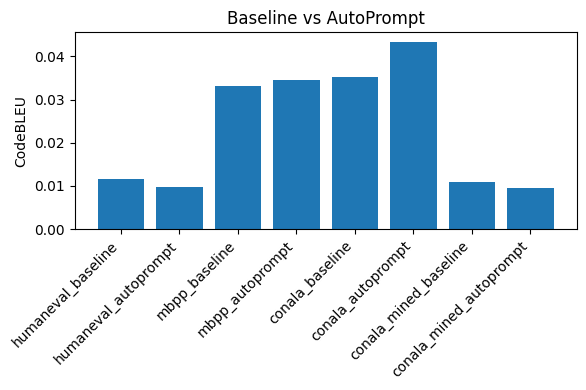

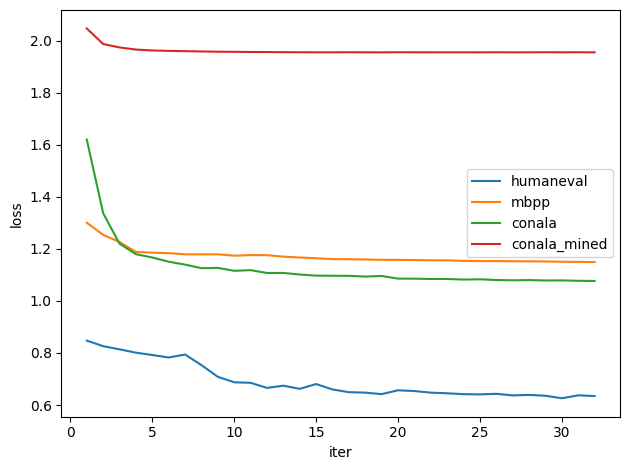

In [9]:
plt.figure(figsize=(6,4))
plt.bar(df['Run'],df['CodeBLEU'])
plt.xticks(rotation=45,ha='right'); plt.ylabel('CodeBLEU')
plt.title('Baseline vs AutoPrompt'); plt.tight_layout()
plt.savefig(SAVE_DIR/'bar_overall.png',dpi=150); plt.show()
for n,l in loss_log.items():
    plt.plot(range(1,len(l)+1),l,label=n)
plt.legend(); plt.xlabel('iter'); plt.ylabel('loss'); plt.tight_layout()
plt.savefig(SAVE_DIR/'loss_curve.png',dpi=150); plt.show()

In [14]:
# ╒════════════════════════════════════════╕
# | Visualization of metrics              |
# ╘════════════════════════════════════════╛
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./results/full_20250629_152057/metrics_full.csv")

# Извлекаем dataset и method из названия запуска
df['dataset'] = df['Run'].str.extract(r'^(.*?)_')
df['method'] = df['Run'].str.extract(r'_(baseline|autoprompt)$')

# Удаляем дубликаты (если есть)
df = df.drop_duplicates(subset=['dataset', 'method'], keep='first')

In [15]:
print(df.columns)

Index(['Run', 'EM', 'CodeBLEU', 'Latency', 'dataset', 'method'], dtype='object')


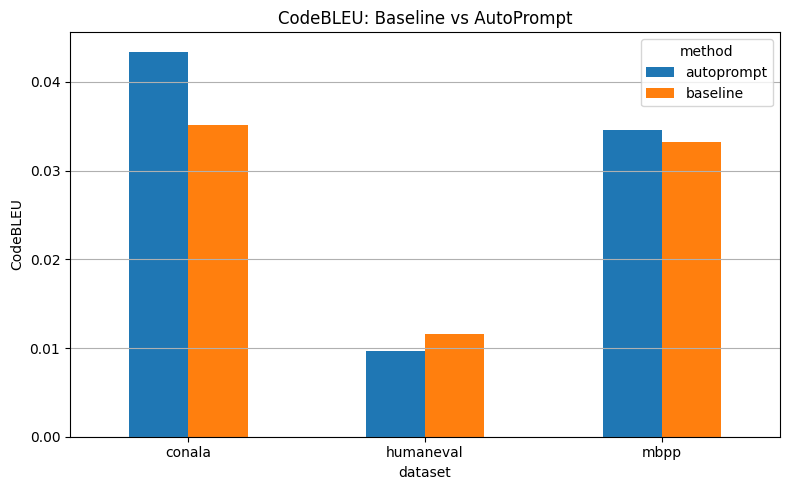

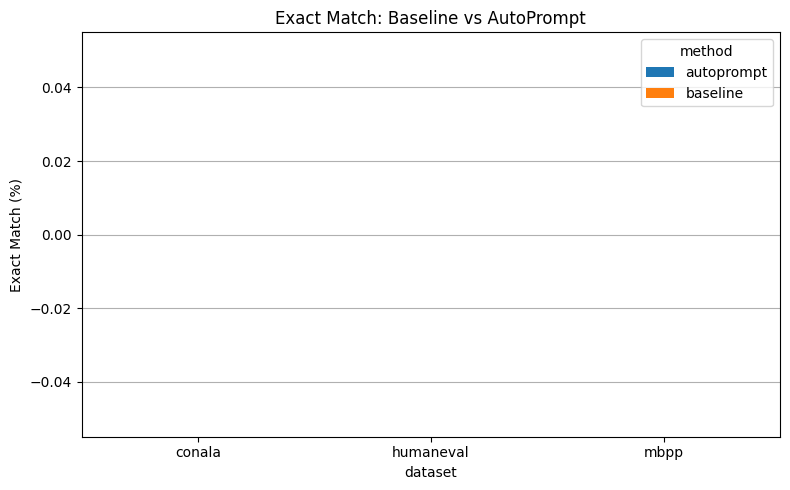

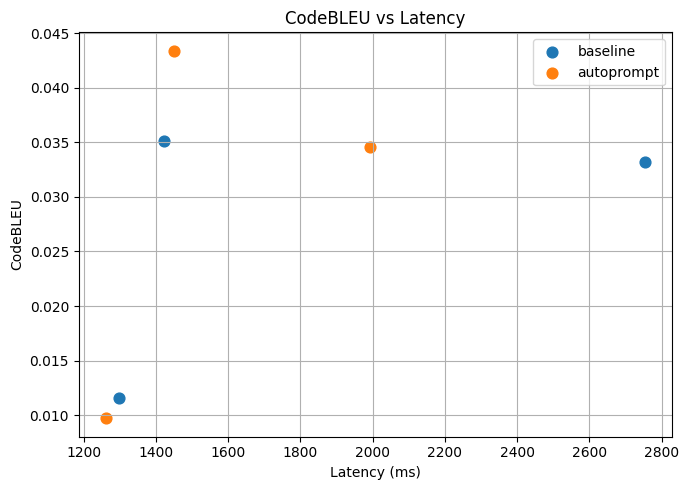

In [17]:
# Pivot-таблицы
pivot_codebleu = df.pivot(index='dataset', columns='method', values='CodeBLEU')
pivot_em = df.pivot(index='dataset', columns='method', values='EM')
pivot_latency = df.pivot(index='dataset', columns='method', values='Latency')

# ── Bar chart: CodeBLEU ─────────────────────
pivot_codebleu.plot(kind='bar', figsize=(8, 5))
plt.ylabel("CodeBLEU")
plt.title("CodeBLEU: Baseline vs AutoPrompt")
plt.xticks(rotation=0)
plt.grid(axis='y'); plt.tight_layout()
plt.savefig("bar_codebleu_comparison.png", dpi=150)
plt.show()

# ── Bar chart: Exact Match ──────────────────
pivot_em.plot(kind='bar', figsize=(8, 5))
plt.ylabel("Exact Match (%)")
plt.title("Exact Match: Baseline vs AutoPrompt")
plt.xticks(rotation=0)
plt.grid(axis='y'); plt.tight_layout()
plt.savefig("bar_em_comparison.png", dpi=150)
plt.show()

# ── Scatter: Latency vs CodeBLEU ────────────
plt.figure(figsize=(7, 5))
for m in df['method'].unique():
    subset = df[df['method'] == m]
    plt.scatter(subset['Latency'], subset['CodeBLEU'], label=m, s=60)

plt.xlabel("Latency (ms)")
plt.ylabel("CodeBLEU")
plt.title("CodeBLEU vs Latency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("scatter_codebleu_vs_latency.png", dpi=150)
plt.show()
